In [1]:
from src.clp_zne.utils import (
    intercept_uncertainty_unweighted,
    estimate_observable_from_counts,
    compute_std_average_observable,
    to_qiskit_counts_format,
    simulate_density_matrix, 
    transpile_to_layouts,
    cyclic_permutations,
    sample_bitstrings,
    sum_gate_errors,
    compute_evals,
    add_hadamards,
)
from src.clp_zne.qpu_info.layout_cycles import heron_layout_cycles_12q
from src.clp_zne.hamiltonians import sherrington_kirkpatrick_model
from src.clp_zne.qpu_info.backends import FakeTorino

from qiskit_aer.noise import NoiseModel
from qiskit.circuit.library import TwoLocal

from matplotlib import pyplot as plt
import matplotlib
from tqdm import tqdm
import numpy as np

import os

### The Setup

In [2]:
# Load CLP-ZNE data (without shot-noise)
folder_name = ".\\data\\FakeTorino--Cyclic circuit--12 qubits--Orig noise--CLP ZNE 1 param 2 cycles"

evals_ideal = np.load(os.path.join(folder_name, 'evals_ideal.npy'))
evals_mitigated = np.load(os.path.join(folder_name, 'evals_mitigated.npy'))
evals_noisy = np.load(os.path.join(folder_name, 'evals_noisy.npy'))
error_sums = np.load(os.path.join(folder_name, 'error_sums.npy'))

In [3]:
N_QUBITS = 12

backend = FakeTorino()
target = backend.target

observables = [sherrington_kirkpatrick_model(N_QUBITS, h=1, seed=i) for i in range(100)]

circuits = []
for i in range(20):
    circ = TwoLocal(N_QUBITS, ['rx', 'rz'], 'cz', entanglement="circular", reps=3)
    rng = np.random.default_rng(i)
    parameters = rng.uniform(-np.pi, np.pi, circ.num_parameters)
    circ.assign_parameters(parameters, inplace=True)
    circuits.append(circ)
    
noise_model = NoiseModel.from_backend(backend, readout_error=False, gate_error=True, thermal_relaxation=True)

In [4]:
# Choose problem instance to plot
INDEX_OF_OBSERVABLE = 43
INDEX_OF_CIRCUIT = 4
N_SHOTS = 10_000 # number of shots per basis per circuit layout

observable = observables[INDEX_OF_OBSERVABLE]
circuit = circuits[INDEX_OF_CIRCUIT]

### Compute noisy expectation values

#### CLP-ZNE

In [5]:
# CLP-ZNE layouts
cyclic_layouts = []
for cycle in [heron_layout_cycles_12q[5], heron_layout_cycles_12q[16]]:
    cyclic_layouts.extend(cyclic_permutations(cycle))

# Circuit transpilation
circuit_x = add_hadamards(circuit)
transpiled_circuits = transpile_to_layouts(circuit, cyclic_layouts, target)
transpiled_circuits_x = transpile_to_layouts(circuit_x, cyclic_layouts, target)

# Compute exact probabilities for each outcome in Z nad X bases
prob_vectors_z = []
prob_vectors_x = []
for i in tqdm(range(len(cyclic_layouts))):
    rho_qiskit = simulate_density_matrix(transpiled_circuits[i], layout=cyclic_layouts[i], noise_model=noise_model)
    prob_vectors_z.append(np.diag(rho_qiskit).real.astype(np.float64))
    rho_qiskit = simulate_density_matrix(transpiled_circuits_x[i], layout=cyclic_layouts[i], noise_model=noise_model)
    prob_vectors_x.append(np.diag(rho_qiskit).real.astype(np.float64))

# Compute exact standard deviation of the layout-averaged noisy observable for each of the two selected qubit cycles.
std_average_1, _ = compute_std_average_observable(observable, prob_vectors_z[:N_QUBITS],
                                                          prob_vectors_x[:N_QUBITS], n_shots=N_SHOTS)
std_average_2, _ = compute_std_average_observable(observable, prob_vectors_z[N_QUBITS:],
                                                          prob_vectors_x[N_QUBITS:], n_shots=N_SHOTS)

# Sample shots
samples_z = [sample_bitstrings(prob_vector, n_shots=N_SHOTS, seed=833) for prob_vector in prob_vectors_z]
samples_x = [sample_bitstrings(prob_vector, n_shots=N_SHOTS, seed=5539) for prob_vector in prob_vectors_x]

# Estimate noisy expectation values using shots
sampled_ev = []
for i in range(len(cyclic_layouts)):
    qiskit_samples_z = to_qiskit_counts_format(samples_z[i])
    qiskit_samples_x = to_qiskit_counts_format(samples_x[i])
    res = estimate_observable_from_counts(observable, qiskit_samples_z, qiskit_samples_x)
    sampled_ev.append(res['expval_H'])

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [05:18<00:00, 13.28s/it]


#### LP-ZNE (Random layouts)

In [6]:
# Choose the same number of random layouts with small noise (total infidelity of gates < 1)
rng_for_transpilation = np.random.default_rng(142)
cycles_with_small_noise = [heron_layout_cycles_12q[i] for i in [1, 2, 4, 5, 7, 8, 9, 13, 16, 17]]
available_layouts = []
for cycle in cycles_with_small_noise:
    available_layouts.extend(cyclic_permutations(cycle))
    available_layouts.extend(cyclic_permutations(cycle[::-1]))
random_indxs = rng_for_transpilation.choice(len(available_layouts), size=len(cyclic_layouts), replace=False).tolist()
random_layouts = [available_layouts[i] for i in random_indxs]

# Circuit transpilation
circuit_x = add_hadamards(circuit)
transpiled_circuits = transpile_to_layouts(circuit, random_layouts, target)
transpiled_circuits_x = transpile_to_layouts(circuit_x, random_layouts, target)

# Compute exact probabilities for each outcome in Z nad X bases
prob_vectors_z_rl = []
prob_vectors_x_rl = []
for i in tqdm(range(len(random_layouts))):
    rho_qiskit = simulate_density_matrix(transpiled_circuits[i], layout=random_layouts[i], noise_model=noise_model)
    prob_vectors_z_rl.append(np.diag(rho_qiskit).real.astype(np.float64))
    rho_qiskit = simulate_density_matrix(transpiled_circuits_x[i], layout=random_layouts[i], noise_model=noise_model)
    prob_vectors_x_rl.append(np.diag(rho_qiskit).real.astype(np.float64))

# Compute exact noisy values
evals_noisy_rl = compute_evals(
                            transpiled_circuits, 
                            layouts=np.array(random_layouts),
                            observables=[observable], 
                            noise_model=noise_model)

# Get total gate errors
errors_rl = [sum_gate_errors(tcirc, noise_model) for tcirc in tqdm(transpiled_circuits)]

# Compute exact standard deviation of the noisy observable for each random layout
std_rl = []
for i in tqdm(range(len(random_layouts))):
    std, _ = compute_std_average_observable(observable, [prob_vectors_z_rl[i]], 
                                            [prob_vectors_x_rl[i]], n_shots=N_SHOTS)
    std_rl.append(std)
    
# Sample shots
samples_z_rl = [sample_bitstrings(prob_vector, n_shots=N_SHOTS, seed=88) for prob_vector in prob_vectors_z_rl]
samples_x_rl = [sample_bitstrings(prob_vector, n_shots=N_SHOTS, seed=65) for prob_vector in prob_vectors_x_rl]

# Estimate noisy expectation values using shots
sampled_ev_rl = []
for i in range(len(random_layouts)):
    qiskit_samples_z_rl = to_qiskit_counts_format(samples_z_rl[i])
    qiskit_samples_x_rl = to_qiskit_counts_format(samples_x_rl[i])
    res_rl = estimate_observable_from_counts(observable, qiskit_samples_z_rl, qiskit_samples_x_rl)
    sampled_ev_rl.append(res_rl['expval_H'])

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:21<00:00,  1.14it/s]


### Plot Zero Noise Extrapolation

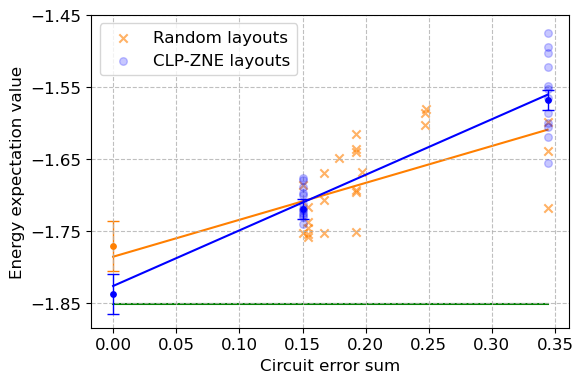

In [8]:
# This plot contains both the values obtained usnig shots and
# the exact values obtained via full density matrix simulations.
# Exact values have subscript _true and are shown on the plot 
# with solid dots (with thier respective errorbars). In contrast,
# shot-based values are shown on the plot with either crosses or
# semi-transparet circles.

# Extract ideal and noisy values for the chosen circuit/observable
ev_ideal = evals_ideal[INDEX_OF_CIRCUIT][INDEX_OF_OBSERVABLE]
y_true = evals_noisy[INDEX_OF_CIRCUIT][INDEX_OF_OBSERVABLE]

# Prepare x and y arrays for CLP-ZNE layouts
x = np.array([[error_sums[INDEX_OF_CIRCUIT][0].item()] * N_QUBITS, 
              [error_sums[INDEX_OF_CIRCUIT][1].item()] * N_QUBITS]).ravel()
y = sampled_ev
sigmas_true = [std_average_1, std_average_2]
x1, x2 = x[0], x[-1]

# Prepare x and y arrays for random layouts
x_rl = np.array(errors_rl).ravel()
y_rl = sampled_ev_rl
y_true_rl = evals_noisy_rl[0]

# Linear fits for CLP-ZNE layouts
m, b = np.polyfit(np.mean(np.array(x).reshape(2, -1), axis=1), 
                  np.mean(np.array(sampled_ev).reshape(2, -1), axis=1), 1)
m_true, b_true = np.polyfit(np.mean(np.array(x).reshape(2, -1), axis=1), 
                            np.mean(np.array(y_true).reshape(2, -1), axis=1), 1)
sigma_b_true = intercept_uncertainty_unweighted(np.array([x1, x2]), np.array(sigmas_true))

# Linear fits for random layouts
m_rl, b_rl = np.polyfit(x_rl, y_rl, 1)
m_true_rl, b_true_rl = np.polyfit(x_rl, y_true_rl, 1)
sigma_b_true_rl = intercept_uncertainty_unweighted(np.array(x_rl), np.array(std_rl))

# Plot styling
font = {'weight': 'normal', 'size': 12}
matplotlib.rc('font', **font)
plt.figure(figsize=(6, 4), facecolor='w', edgecolor='b')

# Scatter CLP-ZNE data points
plt.scatter(x, y, label='CLP-ZNE layouts', color='b', s=30, zorder=3, alpha=0.22)

# Error bars for CLP-ZNE means and extrapolations
plt.errorbar(x=[x1, x2], y=[np.mean(y_true[:N_QUBITS]), np.mean(y_true[N_QUBITS:])],
             yerr=sigmas_true, color='b', zorder=4, elinewidth=1, capsize=4, linestyle='None')
plt.errorbar(x=[0], y=b_true, yerr=sigma_b_true,
             color='b', zorder=4, elinewidth=1, capsize=4, linestyle='None')

# Error bar for random extrapolation
plt.errorbar(x=[0], y=b_true_rl, yerr=sigma_b_true_rl,
             color='#ff7f00', zorder=1, elinewidth=1, capsize=4, linestyle='None')

# Highlighted points for means and extrapolations
plt.scatter(x=[x1, x2], y=[np.mean(y_true[:N_QUBITS]), np.mean(y_true[N_QUBITS:])],
            color='b', s=15, zorder=6)
plt.scatter(x=[0], y=[b_true], color='b', s=15, zorder=6)
plt.scatter(x=[0], y=[b_true_rl], color='#ff7f00', s=15, zorder=6)

# Regression lines
x_regression = np.linspace(0, max(x_rl), 2)
regression_line = m * x_regression + b
regression_line_rl = m_rl * x_regression + b_rl

plt.plot(x_regression, regression_line, color='b', label='_nolegend_', zorder=2)
plt.plot(x_regression, regression_line_rl, color='#ff7f00', label='_nolegend_', zorder=1)

# Noiseless value line
plt.plot(x_regression, ev_ideal * np.ones_like(x_regression), color='g', zorder=1)

# Scatter data points obtained with random layouts
plt.scatter(x_rl, y_rl, color='#ff7f00', alpha=0.6, label="Random layouts", marker='x')

# Labels and axes formatting
plt.ylabel("Energy expectation value")
plt.xlabel('Circuit error sum')
plt.yticks(np.linspace(-1.85, -1.45, 5))

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
handles[:2] = handles[1::-1]
labels[:2] = labels[1::-1]
plt.legend(handles, labels, loc='upper left')

# Grid and display
ax = plt.gca()
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()